 Imports + dataset CIFAR-10

In [1]:
import torch
import torchvision
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # 3 canaux RGB
])

dataset_train = torchvision.datasets.CIFAR10(
    root='./data', train=True,  transform=transform, download=True
)
dataset_test = torchvision.datasets.CIFAR10(
    root='./data', train=False, transform=transform, download=True
)

classes = dataset_train.classes
print(classes)

KeyboardInterrupt: 

Visualiser quelques images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.88235295..0.9764706].


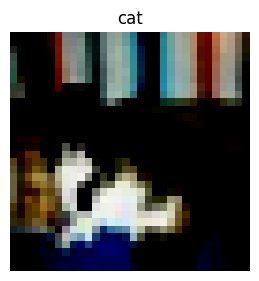

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.84313726..1.0].


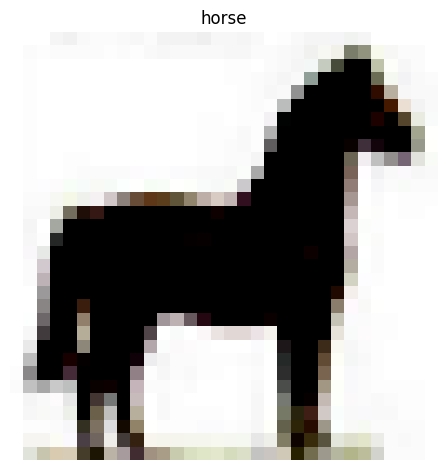

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6784314..0.60784316].


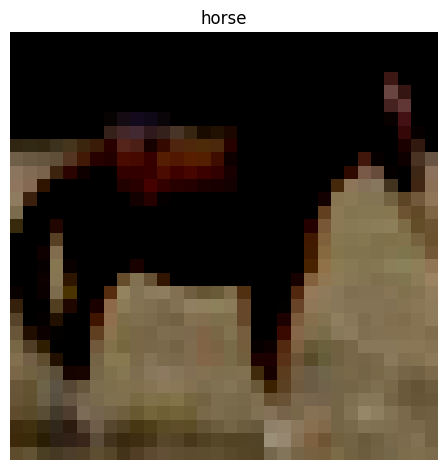

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5529412..0.9843137].


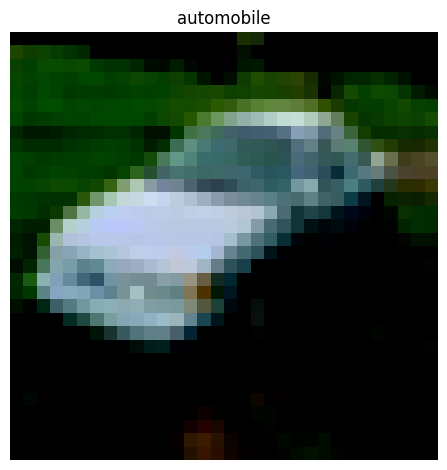

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.827451..0.92941177].


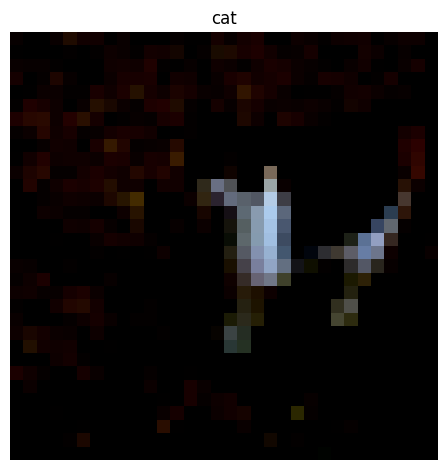

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9764706].


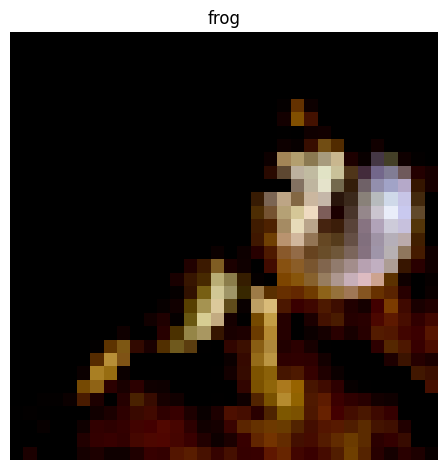

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.81960785..0.67058825].


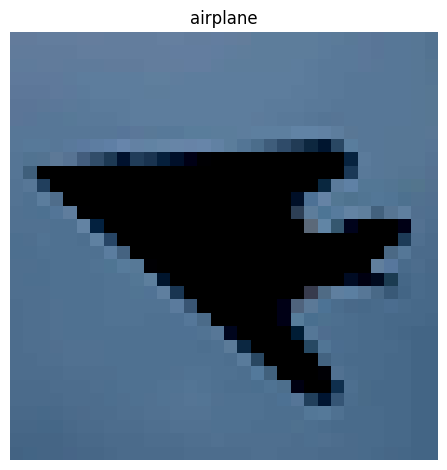

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6313726].


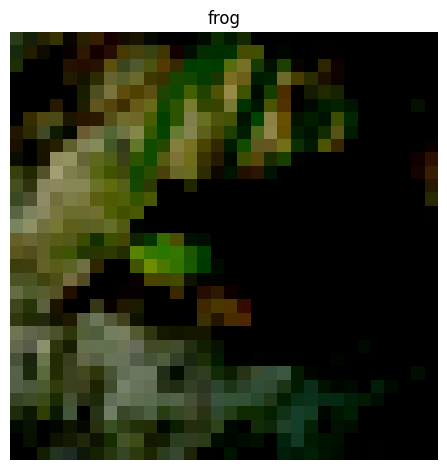

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.75686276].


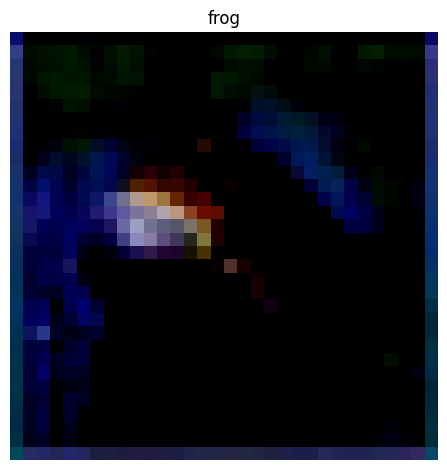

In [ ]:
figure = plt.figure(figsize=(8,8))
cols, rows = 3, 3

for i in range(1, cols*rows + 1):
    sample_idx = torch.randint(len(dataset_train), size=(1,)).item()
    img, label = dataset_train[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(classes[label])
    plt.axis("off")
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))

    plt.tight_layout()
    plt.show()

 DataLoader

In [ ]:
dataloader_train = DataLoader(dataset_train, batch_size=64, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)

train_features, train_labels = next (iter(dataloader_train))
print(f"Feature batch shape: {train_features.size()}")

Feature batch shape: torch.Size([64, 3, 32, 32])


Définition du modèle

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),   # normalise les 32 cartes
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),   # normalise les 64 cartes
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.model(x)

def train_loop(dataloader, model, criterion, optimizer, writer, epoch):
    size = len(dataloader.dataset)
    model.train()
    loop = tqdm(dataloader, desc='Train')
    for batch, (x, y) in enumerate(loop):
        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loop.set_postfix(loss=loss.item())
        
        # Log la loss chaque batch
        global_step = epoch * len(dataloader) + batch
        writer.add_scalar('Loss/train', loss.item(), global_step)

def test_loop(dataloader, model, criterion, writer, epoch):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in tqdm(dataloader, desc='Test'):
            pred = model(x)
            test_loss += criterion(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    
    # Log l'accuracy et la loss de test par epoch
    writer.add_scalar('Loss/test', test_loss, epoch)
    writer.add_scalar('Accuracy/test', 100 * correct, epoch)
    
    print(f'Accuracy : {(100*correct):>0.1f}%, Avg loss : {test_loss:>8f}\n')

In [ ]:
torch.manual_seed(42)

# Initialiser TensorBoard writer
writer = SummaryWriter('runs/cifar10_cnn')

cnn = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(cnn.parameters(), lr=0.01)

writer = SummaryWriter('runs/cifar10_cnn')

epochs = 5
for t in range(epochs):
    print(f'Epoch {t+1}\n-------------------------------')
    train_loop(dataloader_train, cnn, criterion, optimizer, writer, t)
    test_loop(dataloader_test, cnn, criterion, writer, t)

writer.close()
print("TensorBoard logs saved in 'runs/cifar10_cnn'. Launch tensorboard with: tensorboard --logdir=runs")

Epoch 1
-------------------------------


Test: 100%|██████████| 157/157 [00:04<00:00, 36.74it/s]


Accuracy : 50.5%, Avg loss : 1.325546

Epoch 2
-------------------------------


Test: 100%|██████████| 157/157 [00:03<00:00, 39.75it/s]


Accuracy : 58.0%, Avg loss : 1.169283

Epoch 3
-------------------------------


...

Accuracy : 57.6%, Avg loss : 1.157287

Epoch 4
-------------------------------


Test: 100%|██████████| 157/157 [00:03<00:00, 48.20it/s]


Accuracy : 66.4%, Avg loss : 0.956586

Epoch 5
-------------------------------


Test: 100%|██████████| 157/157 [00:03<00:00, 48.54it/s]

Accuracy : 62.0%, Avg loss : 1.076463

TensorBoard logs saved in 'runs/cifar10_cnn'. Launch tensorboard with: tensorboard --logdir=runs


Transfer Learning avec ResNet

In [ ]:
import torchvision.models as models

resnet18 = models.resnet18(pretrained=True)

for param in resnet18.parameters():
    param.requires_grad = False

resnet18.fc = nn.Linear(2048, 10)

optimizer = torch.optim.SGD(resnet18.parameters(), lr=0.01)

Quantization - Réduire la taille du modèle


In [ ]:
# Quantization dynamique (nouvelle API PyTorch - torchao)
# Plus simple: quantize seulement les poids sans calibration

import torch.quantization as quantization

# Approche 1: Quantization dynamique (recommandée - plus simple, pas de calibration)
cnn_quantized = quantization.quantize_dynamic(
    cnn,
    {nn.Linear},  # quantize les couches Linear
    dtype=torch.qint8
)

# Vérifier la taille du modèle
original_size = sum(p.numel() for p in cnn.parameters())
quantized_size = sum(p.numel() for p in cnn_quantized.parameters())

print(f"Original model size: {original_size / 1e6:.2f} MB")
print(f"Quantized model size: {quantized_size / 1e6:.2f} MB")
print(f"Compression ratio: {original_size / quantized_size:.2f}x")

/var/folders/bg/36y8k9sn4r90mjdwrm9r0gx00000gn/T/ipykernel_79068/1601012399.py:7: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  cnn_quantized = quantization.quantize_dynamic(


RuntimeError: Didn't find engine for operation quantized::linear_prepack NoQEngine

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

In [ ]:
model_resnet = resnet18(weights=ResNet18_Weights.DEFAULT)



TypeError: ResNet.forward() got an unexpected keyword argument 'weights'

Geler tous les poids — on ne réentraîne pas les couches existantes

In [ ]:
for param in model_resnet.parameters():
    param.requires_grad = False

 Remplacer la dernière couche pour 10 classes

In [ ]:
# ── ResNet18 ───────────────────────────────────────────────────────────
from torchvision.models import resnet18, ResNet18_Weights

model_resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in model_resnet.parameters():
    param.requires_grad = False

model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 10)

print(model_resnet.fc)
n_params = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f"Paramètres entraînables : {n_params:,}")

Linear(in_features=512, out_features=10, bias=True)
Paramètres entraînables : 5,130


In [ ]:
# ── Entraînement ResNet ────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_resnet.parameters(), lr=0.01)

writer = SummaryWriter('runs/resnet_cifar10')

epochs = 5
for t in range(epochs):
    print(f'Epoch {t+1}\n-------------------------------')
    train_loop(dataloader_train, model_resnet, criterion, optimizer, writer, t)
    test_loop(dataloader_test,   model_resnet, criterion, writer, t)

writer.close()

Epoch 1
-------------------------------


Test: 100%|██████████| 157/157 [00:26<00:00,  5.96it/s]


Accuracy : 44.2%, Avg loss : 1.626560

Epoch 2
-------------------------------


Test: 100%|██████████| 157/157 [00:23<00:00,  6.69it/s]


Accuracy : 43.9%, Avg loss : 1.622203

Epoch 3
-------------------------------


...

Accuracy : 44.6%, Avg loss : 1.593688

Epoch 4
-------------------------------


Test: 100%|██████████| 157/157 [00:24<00:00,  6.29it/s]


Accuracy : 44.3%, Avg loss : 1.601580

Epoch 5
-------------------------------


Test: 100%|██████████| 157/157 [01:04<00:00,  2.45it/s]

Accuracy : 44.6%, Avg loss : 1.582431



Accuracy  : 0.6198
F1-macro  : 0.6155


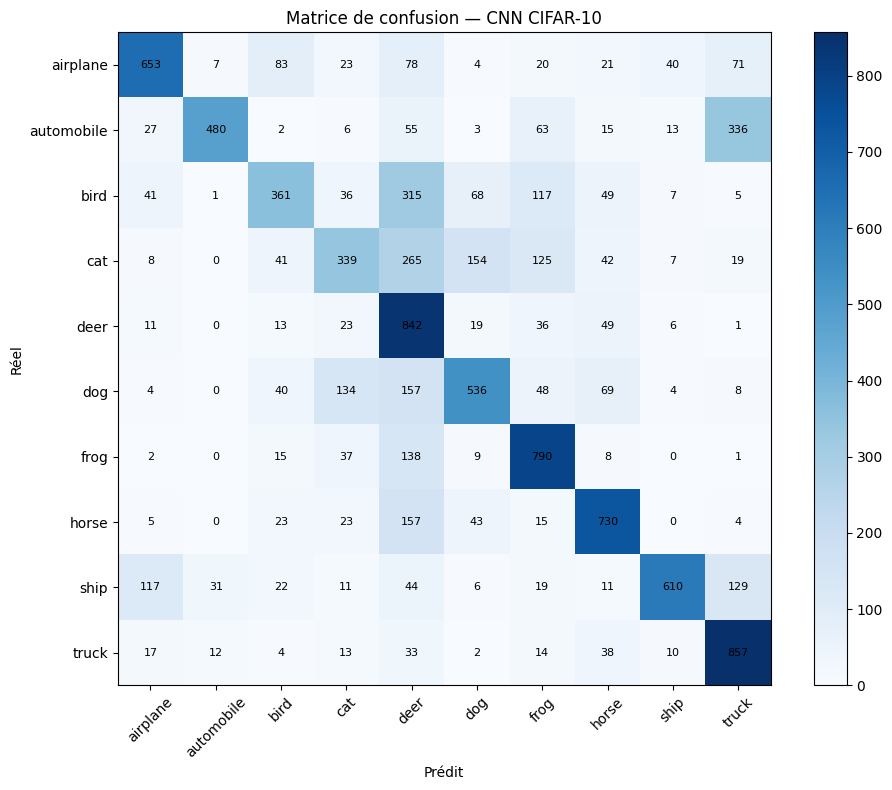

In [ ]:
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score, MulticlassConfusionMatrix
import matplotlib.pyplot as plt

accuracy_metric = MulticlassAccuracy(num_classes=10)
f1_metric       = MulticlassF1Score(num_classes=10, average='macro')
cm_metric       = MulticlassConfusionMatrix(num_classes=10)

cnn.eval()
with torch.no_grad():
    for x, y in dataloader_test:
        pred = cnn(x)
        accuracy_metric.update(pred, y)
        f1_metric.update(pred, y)
        cm_metric.update(pred, y)

acc = accuracy_metric.compute()
f1  = f1_metric.compute()
cm  = cm_metric.compute()

print(f"Accuracy  : {acc:.4f}")
print(f"F1-macro  : {f1:.4f}")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm.numpy(), cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(classes, rotation=45)
ax.set_yticklabels(classes)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title('Matrice de confusion — CNN CIFAR-10')

for i in range(10):
    for j in range(10):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
import torch.onnx

# export du modèle en ONNX
dummy_input = torch.randn(1, 3, 32, 32)  # une image fictive RGB 32x32
torch.onnx.export(
    cnn,
    dummy_input,
    'cnn_cifar10.onnx',
    input_names=['input'],
    output_names=['output'],
    opset_version=11
)

print("Modèle exporté : cnn_cifar10.onnx")

# vérifier la taille du fichier
import os
size_mb = os.path.getsize('cnn_cifar10.onnx') / 1e6
print(f"Taille : {size_mb:.2f} MB")

W0610 13:05:12.189000 79068 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/Users/laly/Sites/A4/IA Analyse prédictive/.venv/lib/python3.13/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/Users/laly/Sites/A4/IA Analyse prédictive/.venv/lib/python3.13/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Modèle exporté : cnn_cifar10.onnx
Taille : 0.02 MB


In [6]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'transformers'])



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


CompletedProcess(args=['/Users/laly/Sites/A4/IA Analyse prédictive/.venv/bin/python', '-m', 'pip', 'install', 'transformers'], returncode=0)

In [11]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
import torch

model_name = "aaraki/vit-base-patch16-224-in21k-finetuned-cifar10"

extractor = AutoImageProcessor.from_pretrained(model_name)
model_hf  = AutoModelForImageClassification.from_pretrained(model_name)
model_hf.eval()

print("Modèle chargé :", model_name)
print("Classes :", model_hf.config.id2label)

KeyboardInterrupt: 

In [ ]:
correct = 0
total   = 100

dataset_test_raw = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False
)

for i in range(total):
    img, label = dataset_test_raw[i]
    inputs = extractor(images=img, return_tensors="pt")

    with torch.no_grad():
        outputs = model_hf(**inputs)

    pred = outputs.logits.argmax(-1).item()
    if pred == label:
        correct += 1

print(f"Accuracy Hugging Face ViT : {correct / total * 100:.1f}%")